### Author: B282025 <br>
### MSc Bioinformatics Dissertation <br>
### August 2026 <br>

Description: This notebook performs cell type assignment and generates plots to analyze fibronectin positive cells.<br>

Reference: This code was written using a combination of manual scripting and Claude Sonnet 5.

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# ---------------------------------------------------------------------
# Shared plot styling (kept identical across all analysis notebooks)
# ---------------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "savefig.bbox": "tight",
})

In [3]:
# READ IN DATA
df = pd.read_csv('../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_cell_typed_detection_measurements.tsv', sep='\t')

/var/folders/99/xct0l8b508x0rlqmy0gj6mc80000gn/T/ipykernel_1148/3821018385.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_cell_typed_detection_measurements.tsv', sep='\t')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995017 entries, 0 to 995016
Columns: 846 entries, Image to Cell: DRAQ5: Std.Dev.
dtypes: float64(590), int64(246), object(10)
memory usage: 6.3+ GB


In [5]:
df.head()

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Structural Region,...,Cell: Pan-Cytokeratin: Mean,Cell: Pan-Cytokeratin: Median,Cell: Pan-Cytokeratin: Min,Cell: Pan-Cytokeratin: Max,Cell: Pan-Cytokeratin: Std.Dev.,Cell: DRAQ5: Mean,Cell: DRAQ5: Median,Cell: DRAQ5: Min,Cell: DRAQ5: Max,Cell: DRAQ5: Std.Dev.
0,PPJ_07_2_Scan1_DB_cell_typed.qptiff,f7a3b208-5fef-4596-bfc6-ee811b0c3b1a,Cell,NaN,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell:...,Annotation (Tissue),Polygon,8129.2,18096.2,NaN,...,0.3750,0.0,0,1,0.4880,25.6406,24.0,3,49,12.9423
1,PPJ_07_2_Scan1_DB_cell_typed.qptiff,83f92b7f-71fb-4a82-b8b3-12c4e06b800d,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8118.4,18096.3,NaN,...,0.6489,1.0,0,2,0.6493,21.3404,18.5,2,50,13.6774
2,PPJ_07_2_Scan1_DB_cell_typed.qptiff,117d8be0-7cb1-41e2-8747-339404f42713,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8106.6,18097.5,NaN,...,0.8273,1.0,0,3,0.7402,7.1182,6.5,1,14,3.4073
3,PPJ_07_2_Scan1_DB_cell_typed.qptiff,0d00f8cd-0f7d-4765-9835-e291c52c88d0,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8111.8,18099.6,NaN,...,0.9580,1.0,0,3,0.7178,18.0000,18.0,4,32,7.9873
4,PPJ_07_2_Scan1_DB_cell_typed.qptiff,d5f5430a-8b08-4199-8dcb-7a105c95c6a0,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8116.8,18102.9,NaN,...,0.9774,1.0,0,2,0.5834,42.0301,43.0,6,79,20.2787


In [6]:
print(df.columns[:20])

Index(['Image', 'Object ID', 'Object type', 'Name', 'Classification', 'Parent',
       'ROI', 'Centroid X µm', 'Centroid Y µm', 'Structural Region', 'Tissue',
       'Category', 'Description', 'Nucleus: Area µm^2', 'Nucleus: Length µm',
       'Nucleus: Circularity', 'Nucleus: Solidity', 'Nucleus: Max diameter µm',
       'Nucleus: Min diameter µm', 'Cell: Area µm^2'],
      dtype='object')


In [7]:
df['Classification'].value_counts()

Classification
Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-                             249823
Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-                               72013
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb: SMA                             55476
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb: SMA-                            49886
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-                           49317
                                                                                                 ...  
Non-Tubular Cell: Vcam1: p21: CD45: CD68: Non-Glom Cell: Vimentin: PDGFRb-: SMA: Fibronectin         1
Non-Tubular Cell: Vcam1: CD45: CD68-: Non-Glom Cell: Vimentin-: PDGFRb: SMA: Fibronectin             1
Non-Tubular Cell: Vcam1: Ki67: CD45: CD68-: Glom Cell: Vimentin: PDGFRb-: SMA: Fibronectin           1
Non-Tubular Cell: Vcam1: CD45: CD68: Glom Cell: Vimentin: 

In [8]:
# Confirm the exact string used for vascular cells before running the classifier below.
df['Structural Region'].value_counts()

Structural Region
Vascular    60920
Name: count, dtype: int64

In [9]:
df['Category'].value_counts()

Category
ObK        708677
Non-ObK    286340
Name: count, dtype: int64

## Cell type definitions

Each cell type is defined using the rules below and the the markers parsed out of the Classification column. 

Exception: Vascular cells are identified structurally, via the Structural Region column (spatial containment tagged in QuPath), not via marker rules, and are checked first.

Any cell matching more than one rule below is labeled Ambiguous. Cells that don't fit any of the defined cell types are marked as Unclassified.

In [10]:
# Column names in the input TSV.
CLASSIFICATION_COL = "Classification"
CATEGORY_COL = "Category"

# Written by CellTyping.groovy as a cell metadata column
STRUCTURAL_REGION_COL = "Structural Region"

# The marker that flags Fibronectin positivity.
FIBRONECTIN_MARKER = "Fibronectin"

# Vascular cells are defined structurally (by spatial containment, tagged in
# QuPath), not by markers.
VASCULAR_LABEL = "Vascular cells"
STRUCTURAL_REGION_VASCULAR_VALUE = "Vascular"

# Labels for cells that don't resolve to exactly one type.
UNCLASSIFIED_LABEL = "Unclassified"
AMBIGUOUS_LABEL = "Ambiguous"


def parse_markers(classification: str) -> dict:
    """Parse a Classification string like
    'Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-'
    into a dict of {marker_name: True/False}.

    Handles three token conventions:
      - 'MarkerName'  -> True
      - 'MarkerName-' -> False
      - 'Non-Tubular Cell' / 'Non-Glom Cell' -> special-cased to
        {'Tubular Cell': False} / {'Glom Cell': False}
    """
    if pd.isna(classification):
        return {}
    markers = {}
    for tok in classification.split(":"):
        tok = tok.strip()
        if not tok:
            continue
        if tok == "Non-Tubular Cell":
            markers["Tubular Cell"] = False
        elif tok == "Non-Glom Cell":
            markers["Glom Cell"] = False
        elif tok.endswith("-"):
            markers[tok[:-1]] = False
        else:
            markers[tok] = True
    return markers


# Each rule takes the parsed marker dict and returns True/False.
# Vcam1/p21/Ki67 use .get(..., False) since they may be entirely absent (= negative).
# Markers that are always scored (Tubular Cell, Glom Cell, CD45, CD68, Vimentin,
# PDGFRb, SMA) use direct indexing.

CELL_TYPE_RULES = {
    "Healthy Tubule": lambda m: (
        m["Tubular Cell"]
        and not m.get("Vcam1", False)
        and not (m.get("p21", False) and not m.get("Ki67", False))
    ),
    "Injured Tubule":   lambda m: (
            m["Tubular Cell"] and m.get("Vcam1", False)
            and not (not m.get("Ki67", False) and m.get("p21", False))  # exclude the Senescent pattern
        ),
    "Senescent Tubule": lambda m: (
        m["Tubular Cell"] and not m.get("Ki67", False) and m.get("p21", False)
    ),
    "Macrophages": lambda m: m["CD45"] and m["CD68"],
    "Non-macrophage immune cells": lambda m: m["CD45"] and not m["CD68"],
    "Glomeruli cells": lambda m: m["Glom Cell"],
    # NOTE: Fibroblasts/Myofibroblasts are defined by PDGFRb/SMA status only.
    # Vimentin is intentionally not required, since Vimentin-negative 
    # fibroblasts/myofibroblasts may occur and should still be assigned to a 
    # type rather than being left Unclassified, according to David.
    "Fibroblasts": lambda m: (
        m["PDGFRb"] and not m["SMA"] and not m["Glom Cell"]
    ),
    "Myofibroblasts": lambda m: (
        m["PDGFRb"] and m["SMA"] and not m["Glom Cell"]
    ),
    "Other Mesenchymal Cell": lambda m: (
        m["Vimentin"]
        and not m["PDGFRb"]
        and not m["Tubular Cell"]
        and not m["Glom Cell"]
        and not m["CD45"]
    ),
}


def matching_types(markers: dict, rules: dict) -> list:
    """Return the list of ALL cell type names whose rule matches these markers
    (used to detect ambiguous / overlapping definitions)."""
    return [name for name, rule in rules.items() if rule(markers)]


def assign_cell_type_row(markers: dict, structural_region_value, rules: dict):
    """Returns (assigned_type, all_marker_matches).

    Vascular cells are structural (Structural-Region-based) and are checked first,
    short-circuiting the marker rules entirely. For everything else: 0 marker matches
    -> Unclassified, >1 marker matches -> Ambiguous, exactly 1 -> that type.
    """
    if structural_region_value == STRUCTURAL_REGION_VASCULAR_VALUE:
        return VASCULAR_LABEL, []

    matches = matching_types(markers, rules)
    if len(matches) == 0:
        return UNCLASSIFIED_LABEL, matches
    if len(matches) > 1:
        return AMBIGUOUS_LABEL, matches
    return matches[0], matches

## Summarize the cell types

summarize() assigns every cell to exactly one label (Healthy/Injured/Senescent Tubule,
Macrophages, Non-macrophage immune cells, Glomeruli cells, Fibroblasts, Myofibroblasts,
Other Mesenchymal Cell, Vascular cells, Ambiguous, or Unclassified), then aggregates.
It returns two dataframes: the per-Category/Cell-Type summary, and a table of every cell
that matched more than one type's rule (for sanity-checking the marker definitions).

In [11]:
ALL_LABELS = list(CELL_TYPE_RULES.keys()) + [VASCULAR_LABEL, AMBIGUOUS_LABEL, UNCLASSIFIED_LABEL]


def summarize(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Returns (summary, ambiguous_cells).

    summary: one row per (Category, Cell Type) with Total Cells,
        Fibronectin Positive, Percent Fibronectin Positive.
    ambiguous_cells: rows for every cell whose Classification matched more
        than one defined cell type's rule, showing every type it matched.
    """
    if CLASSIFICATION_COL not in df.columns:
        raise ValueError(f"column '{CLASSIFICATION_COL}' not found in input file.")
    if STRUCTURAL_REGION_COL not in df.columns:
        raise ValueError(f"column '{STRUCTURAL_REGION_COL}' not found in input file.")
    if CATEGORY_COL not in df.columns:
        print(f"WARNING: column '{CATEGORY_COL}' not found; treating all cells as a single category.")
        df = df.copy()
        df[CATEGORY_COL] = "All"

    df = df.copy()

    # Cells with no Category would otherwise be silently dropped by groupby().
    n_missing_category = df[CATEGORY_COL].isna().sum()
    if n_missing_category > 0:
        print(f"NOTE: {n_missing_category} cell(s) have no Category; "
              f"labeling them 'Unknown' rather than dropping them.")
        df[CATEGORY_COL] = df[CATEGORY_COL].fillna("Unknown")

    df["_markers"] = df[CLASSIFICATION_COL].apply(parse_markers)

    assigned = df.apply(
        lambda row: assign_cell_type_row(row["_markers"], row[STRUCTURAL_REGION_COL], CELL_TYPE_RULES),
        axis=1,
    )
    df["Cell Type"] = assigned.apply(lambda x: x[0])
    df["_all_matches"] = assigned.apply(lambda x: x[1])

    # Ambiguity diagnostics: cells that matched more than one type's rule.
    ambiguous_mask = df["Cell Type"] == AMBIGUOUS_LABEL
    ambiguous_cells = df.loc[ambiguous_mask, [CATEGORY_COL, CLASSIFICATION_COL, "_all_matches"]].copy()
    ambiguous_cells = ambiguous_cells.rename(columns={
        CATEGORY_COL: "Category",
        CLASSIFICATION_COL: "Classification",
        "_all_matches": "All Matching Types",
    })
    ambiguous_cells["All Matching Types"] = ambiguous_cells["All Matching Types"].apply(lambda types: ", ".join(types))

    if len(ambiguous_cells) > 0:
        print(f"WARNING: {len(ambiguous_cells)} cell(s) matched more than one cell type's rule. "
              f"These were labeled '{AMBIGUOUS_LABEL}' rather than force-assigned. "
              f"See the ambiguous_cells table for details.")

    rows = []
    for category, cat_df in df.groupby(CATEGORY_COL):
        for cell_type in ALL_LABELS:
            type_df = cat_df[cat_df["Cell Type"] == cell_type]

            total = len(type_df)
            fibro_positive = type_df["_markers"].apply(
                lambda m: m.get(FIBRONECTIN_MARKER, False)
            ).sum()
            percent = (100.0 * fibro_positive / total) if total > 0 else np.nan

            rows.append({
                "Category": category,
                "Cell Type": cell_type,
                "Total Cells": total,
                "Fibronectin Positive": int(fibro_positive),
                "Percent Fibronectin Positive": percent,
            })

    result = pd.DataFrame(rows, columns=[
        "Category", "Cell Type", "Total Cells",
        "Fibronectin Positive", "Percent Fibronectin Positive",
    ])
    result = result.sort_values(["Cell Type", "Category"]).reset_index(drop=True)
    return result, ambiguous_cells

In [12]:
# Run the summary
summary, ambiguous_cells = summarize(df)

In [13]:
summary

,Category,Cell Type,Total Cells,Fibronectin Positive,Percent Fibronectin Positive
0,Non-ObK,Ambiguous,15121,3569,23.602936
1,ObK,Ambiguous,193472,12571,6.497581
2,Non-ObK,Fibroblasts,15990,4743,29.662289
3,ObK,Fibroblasts,63726,6406,10.052412
4,Non-ObK,Glomeruli cells,6477,1742,26.895168
5,ObK,Glomeruli cells,15131,3922,25.920296
6,Non-ObK,Healthy Tubule,171521,7391,4.309093
7,ObK,Healthy Tubule,171252,2340,1.366407
8,Non-ObK,Injured Tubule,1585,72,4.542587
9,ObK,Injured Tubule,31964,1487,4.652109


In [14]:
summary["Category"].value_counts()

Category
Non-ObK    12
ObK        12
Name: count, dtype: int64

There are no Unknown tissue categories, only Non-Obstructed and Obstructed.

In [15]:
ambiguous_cells

,Category,Classification,All Matching Types
261,Non-ObK,Tubular Cell: CD45: CD68-: Non-Glom Cell: Vime...,"Healthy Tubule, Non-macrophage immune cells"
287,Non-ObK,Tubular Cell: CD45-: CD68-: Glom Cell: Vimenti...,"Healthy Tubule, Glomeruli cells"
753,Non-ObK,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,"Healthy Tubule, Fibroblasts"
755,Non-ObK,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Fibroblasts"
772,Non-ObK,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,"Healthy Tubule, Fibroblasts"
...,...,...,...
995005,ObK,Tubular Cell: CD45: CD68-: Non-Glom Cell: Vime...,"Healthy Tubule, Non-macrophage immune cells, M..."
995006,ObK,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Fibroblasts"
995010,ObK,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Fibroblasts"
995013,ObK,Non-Tubular Cell: CD45: CD68: Non-Glom Cell: V...,"Macrophages, Myofibroblasts"


In [16]:
len(ambiguous_cells)

208593

In [17]:
ambiguous_cells["All Matching Types"].value_counts()

All Matching Types
Non-macrophage immune cells, Fibroblasts                          54892
Non-macrophage immune cells, Myofibroblasts                       46276
Healthy Tubule, Fibroblasts                                       21568
Macrophages, Fibroblasts                                          16629
Macrophages, Myofibroblasts                                       16246
Healthy Tubule, Myofibroblasts                                    13546
Healthy Tubule, Non-macrophage immune cells                        6720
Healthy Tubule, Non-macrophage immune cells, Fibroblasts           4329
Non-macrophage immune cells, Glomeruli cells                       4283
Injured Tubule, Fibroblasts                                        3088
Healthy Tubule, Glomeruli cells                                    2721
Healthy Tubule, Non-macrophage immune cells, Myofibroblasts        2638
Healthy Tubule, Macrophages                                        2233
Injured Tubule, Glomeruli cells              

## Counts

Overall Fibronectin+ count, and the total number of cells that didn't resolve cleanly
(Unclassified or Ambiguous).

In [18]:
n_total = len(df)
n_fibro = df["Classification"].apply(lambda c: parse_markers(c).get(FIBRONECTIN_MARKER, False)).sum()
n_unclassified = (summary.loc[summary["Cell Type"] == UNCLASSIFIED_LABEL, "Total Cells"]).sum()
n_ambiguous = (summary.loc[summary["Cell Type"] == AMBIGUOUS_LABEL, "Total Cells"]).sum()
n_unresolved = n_unclassified + n_ambiguous

print(f"Total cells: {n_total}")
print(f"Fibronectin+: {n_fibro} ({n_fibro / n_total:.1%})")
print(f"Unclassified: {n_unclassified} ({n_unclassified / n_total:.1%})")
print(f"Ambiguous: {n_ambiguous} ({n_ambiguous / n_total:.1%})")
print(f"Unclassified + Ambiguous: {n_unresolved} ({n_unresolved / n_total:.1%})")

Total cells: 995017
Fibronectin+: 84381 (8.5%)
Unclassified: 35667 (3.6%)
Ambiguous: 208593 (21.0%)
Unclassified + Ambiguous: 244260 (24.5%)


## Plotting

In [19]:
CATEGORY_COLORS = {
    "Non-ObK": "#87AE73",
    "ObK": "#641226",
}

def _get_category_color(category):
    color = CATEGORY_COLORS.get(category)
    if color is None:
        print(f"WARNING: no color defined for category {category!r}")
        color = "gray"
    return color

In [20]:
# ---------------------------------------------------------------------
# Customize plot colors
# ---------------------------------------------------------------------

CELL_TYPE_COLORS = {
    "Healthy Tubule": "#80b380",
    "Injured Tubule": "#994d00",
    "Senescent Tubule": "#ffe699",
    "Macrophages": "#d514d5",
    "Non-macrophage immune cells": "#4d3399",
    "Glomeruli cells": "#99b3ff",
    "Fibroblasts": "#cc8099",
    "Myofibroblasts": "#ffccb3",
    "Vascular cells": "#800000",
    "Other Mesenchymal Cell": "#0832f8",
    "Unclassified": "#bfbfbf",
    "Ambiguous": "#4d4d4d",
}

# Opacity applied to the Fibronectin- 
FIBRONECTIN_NEG_ALPHA = 1.0

# Edge/border color used around every bar segment.
BAR_EDGE_COLOR = "black"

# Colormap used for the Fibronectin positivity shade in the dot plot
# (plot_cell_type_dotplot).
FIBRONECTIN_CMAP = "Reds"

# Largest dot area in the dot plot
DOT_MAX_SIZE = 400


def _get_cell_type_color(cell_type):
    color = CELL_TYPE_COLORS.get(cell_type)
    return color


In [21]:
def plot_fibronectin_percent(summary: pd.DataFrame) -> None:
    # Exclude Unclassified/Ambiguous cell types from the plot by default.
    plot_summary = summary[
        ~summary["Cell Type"].isin([UNCLASSIFIED_LABEL, AMBIGUOUS_LABEL])
        & (summary["Category"] != "Unknown")
    ]

    cell_types = list(dict.fromkeys(plot_summary["Cell Type"]))
    categories = list(dict.fromkeys(plot_summary["Category"]))

    x = np.arange(len(cell_types))
    n_cat = max(len(categories), 1)
    width = 0.8 / n_cat

    fig, ax = plt.subplots(figsize=(max(6, len(cell_types) * 1.6), 6))
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

    for i, category in enumerate(categories):
        cat_summary = plot_summary[plot_summary["Category"] == category].set_index("Cell Type")
        values = [cat_summary["Percent Fibronectin Positive"].get(ct, np.nan) for ct in cell_types]
        totals = [cat_summary["Total Cells"].get(ct, 0) for ct in cell_types]
        offset = (i - (n_cat - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=category, color=_get_category_color(category),
                      edgecolor="black", linewidth=0.8)

        # Annotate each bar with n= total cells
        for bar, n in zip(bars, totals):
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f"n={n}", xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Fibronectin Positive (%)")
    ax.set_title("Fibronectin Positivity by Cell Type")
    ax.set_xticks(x)
    ax.set_xticklabels(cell_types, rotation=45, ha="right")
    ax.legend(title="Category")
    fig.tight_layout()
    plt.show()

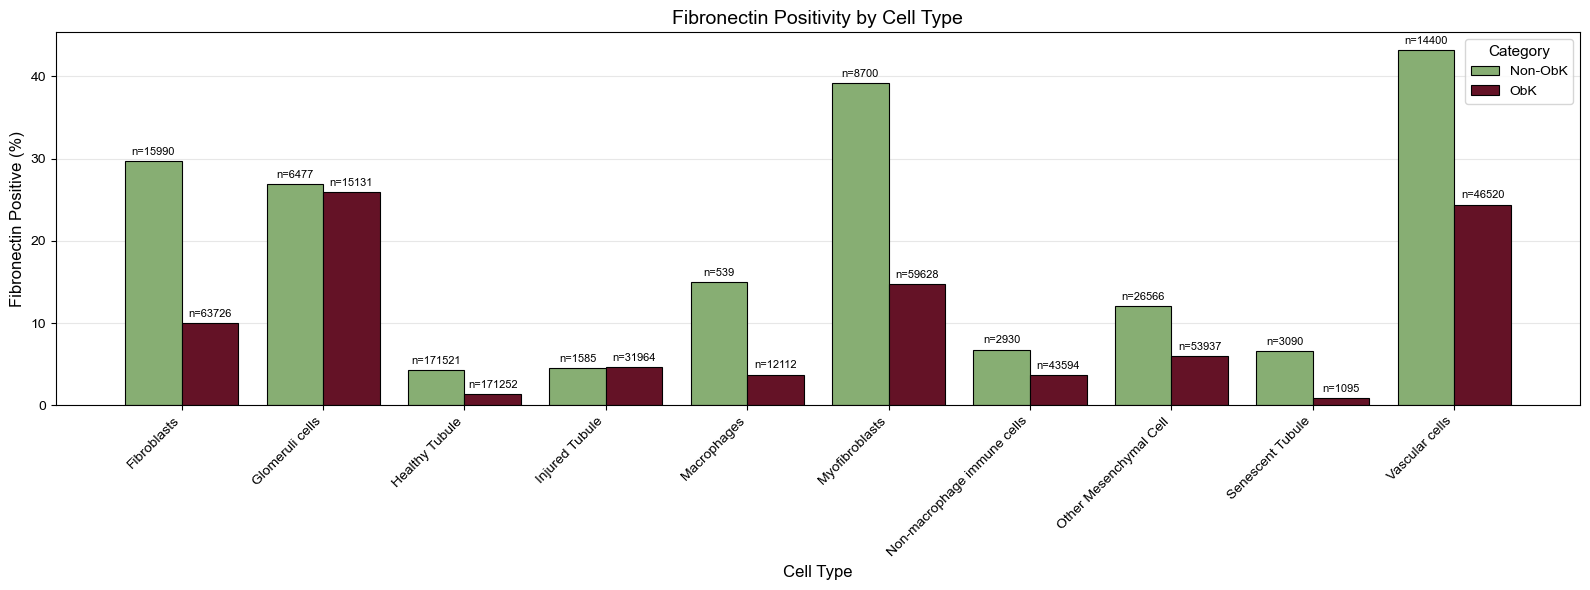

In [22]:
plot_fibronectin_percent(summary)

### Cell type composition by tissue category

Proportion of each cell type within ObK vs. Non-ObK (i.e. each category's bars sum to 100%).

In [23]:
def plot_cell_type_proportions(summary: pd.DataFrame) -> None:
    total_per_category = summary.groupby("Category")["Total Cells"].sum()

    # Include Unclassified/Ambiguous cell types
    plot_summary = summary[summary["Category"] != "Unknown"].copy()
    plot_summary["Proportion"] = plot_summary.apply(
        lambda row: 100.0 * row["Total Cells"] / total_per_category[row["Category"]]
        if total_per_category[row["Category"]] > 0 else np.nan,
        axis=1,
    )

    cell_types = list(dict.fromkeys(plot_summary["Cell Type"]))
    categories = list(dict.fromkeys(plot_summary["Category"]))

    x = np.arange(len(cell_types))
    n_cat = max(len(categories), 1)
    width = 0.8 / n_cat

    fig, ax = plt.subplots(figsize=(max(6, len(cell_types) * 1.6), 6))
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

    for i, category in enumerate(categories):
        cat_summary = plot_summary[plot_summary["Category"] == category].set_index("Cell Type")
        values = [cat_summary["Proportion"].get(ct, np.nan) for ct in cell_types]
        totals = [cat_summary["Total Cells"].get(ct, 0) for ct in cell_types]
        offset = (i - (n_cat - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=category, color=_get_category_color(category),
                      edgecolor="black", linewidth=0.8)

        for bar, n in zip(bars, totals):
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f"n={n}", xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Proportion of Cells in Category (%)")
    ax.set_title("Cell Type Composition by Tissue Category")
    ax.set_xticks(x)
    ax.set_xticklabels(cell_types, rotation=45, ha="right")
    ax.legend(title="Category")
    fig.tight_layout()
    plt.show()

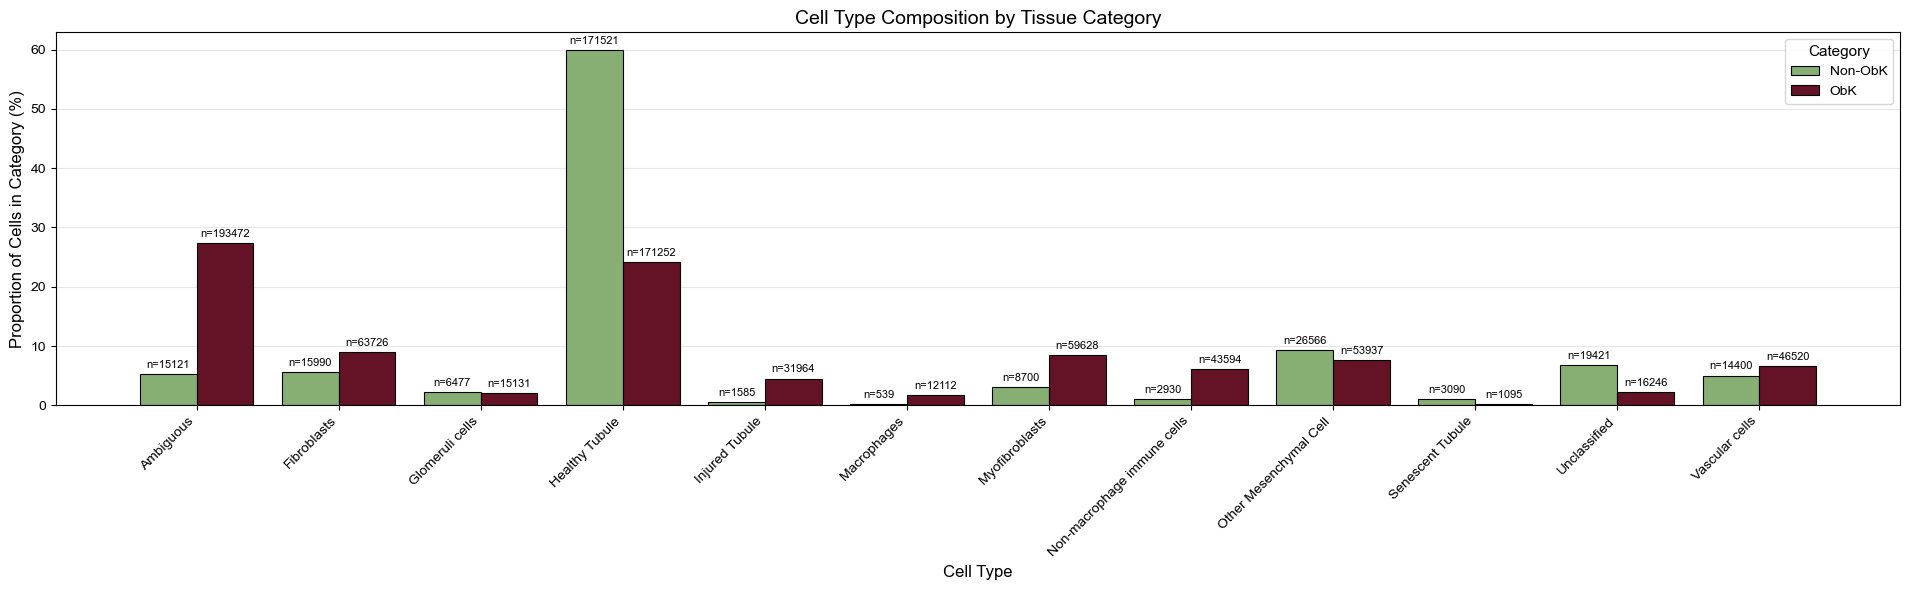

In [24]:
plot_cell_type_proportions(summary)

### Cell type composition by category (stacked bar)

Same underlying counts as the grouped bar chart above, shown instead as one
stacked bar per tissue category, with each segment colored by Cell Type.

In [25]:
def plot_cell_type_stacked_bar(summary: pd.DataFrame, cell_type_order: list = None) -> None:

    plot_summary = summary[summary["Category"] != "Unknown"]

    categories = list(dict.fromkeys(plot_summary["Category"]))

    # Default stacking order: order of first appearance in the data.
    default_order = list(dict.fromkeys(plot_summary["Cell Type"]))

    if cell_type_order is None:
        cell_types = default_order
    else:
        # Use the caller-specified order. Any cell types present in the data
        # but missing from cell_type_order are appended at the end (in their
        # default order) so nothing silently disappears from the chart.
        cell_types = [ct for ct in cell_type_order if ct in default_order]
        cell_types += [ct for ct in default_order if ct not in cell_types]

    # Normalize by the total of the plotted (resolved) cell types per category,
    # so each bar sums to 100%.
    total_per_category = plot_summary.groupby("Category")["Total Cells"].sum()

    fig, ax = plt.subplots(figsize=(max(4, len(categories) * 2.5), 6))
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

    x = np.arange(len(categories))
    bottoms = np.zeros(len(categories))

    # Build the stack of bars. Cell types are stacked bottom-to-top in the
    # order given by `cell_types` (first entry = bottom of the stack).
    for ct in cell_types:
        ct_summary = plot_summary[plot_summary["Cell Type"] == ct].set_index("Category")
        counts = np.array([ct_summary["Total Cells"].get(cat, 0) for cat in categories], dtype=float)
        totals = np.array([total_per_category.get(cat, 0) for cat in categories], dtype=float)
        values = np.divide(counts, totals, out=np.zeros_like(counts), where=totals > 0) * 100.0
        ax.bar(x, values, bottom=bottoms, label=ct, color=_get_cell_type_color(ct),
               edgecolor=BAR_EDGE_COLOR, linewidth=0.8)
        bottoms += values

    ax.set_xlabel("Condition")
    ax.set_ylabel("Proportion of Cells (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Cell Type Composition by Condition")
    ax.set_xticks(x)
    ax.set_xticklabels(categories)

    ax.legend(title="Cell Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.savefig("cell_type_stacked_bar.png", dpi=300, bbox_inches="tight")
    plt.show()


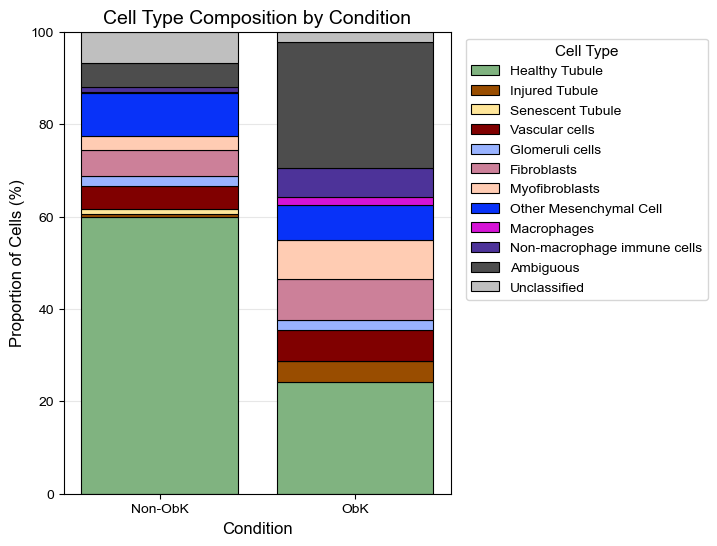

In [26]:
# Specify the stacking order here: first entry = bottom of each bar,
# last entry = top of each bar. Any cell type omitted from this list is
# appended automatically at the end, so you only need to list the ones
# you care about ordering.
CELL_TYPE_STACK_ORDER = [
    "Healthy Tubule",
    "Injured Tubule",
    "Senescent Tubule",
    "Vascular cells",
    "Glomeruli cells",
    "Fibroblasts",
    "Myofibroblasts",
    "Other Mesenchymal Cell",
    "Macrophages",
    "Non-macrophage immune cells",
    "Ambiguous",
    "Unclassified"
]

plot_cell_type_stacked_bar(summary, cell_type_order=CELL_TYPE_STACK_ORDER)


### Cell type proportions table

Table version of the stacked bar chart above: the percentage of each tissue
category's cells that belong to each cell type, using the same stacking
order (`CELL_TYPE_STACK_ORDER`) and normalization (percent of resolved cells
per category).

In [27]:
def summarize_cell_type_proportions(summary: pd.DataFrame, cell_type_order: list = None) -> pd.DataFrame:
    """Table version of plot_cell_type_stacked_bar: proportion (%) of each
    tissue category's cells that fall into each cell type, so the numbers
    behind the stacked bar chart above can be read off directly.

    Rows: Cell Type, ordered using `cell_type_order` (falls back to order
    of first appearance, same rule as the stacked bar chart).
    Columns: Category, renamed to their display names and ordered
    Non-Obstructed then Obstructed (matching the dot plot's convention).
    """
    plot_summary = summary[summary["Category"] != "Unknown"]
    total_per_category = plot_summary.groupby("Category")["Total Cells"].sum()

    counts = plot_summary.pivot_table(
        index="Cell Type", columns="Category", values="Total Cells",
        aggfunc="sum", fill_value=0,
    )
    proportions = counts.div(total_per_category, axis=1) * 100.0

    default_order = list(dict.fromkeys(plot_summary["Cell Type"]))
    if cell_type_order is None:
        row_order = default_order
    else:
        row_order = [ct for ct in cell_type_order if ct in default_order]
        row_order += [ct for ct in default_order if ct not in row_order]
    proportions = proportions.reindex(row_order)

    category_titles = {"Non-ObK": "Non-Obstructed", "ObK": "Obstructed"}
    col_order = [c for c in category_titles if c in proportions.columns]
    col_order += [c for c in proportions.columns if c not in col_order]
    proportions = proportions[col_order]
    proportions = proportions.rename(columns=category_titles)
    proportions = proportions.rename(columns=lambda c: f"{c} (%)")

    return proportions.round(2)


cell_type_proportions = summarize_cell_type_proportions(summary, cell_type_order=CELL_TYPE_STACK_ORDER)
cell_type_proportions

Category,Non-Obstructed (%),Obstructed (%)
Cell Type,,
Healthy Tubule,59.90,24.17
Injured Tubule,0.55,4.51
Senescent Tubule,1.08,0.15
Vascular cells,5.03,6.56
Glomeruli cells,2.26,2.14
Fibroblasts,5.58,8.99
Myofibroblasts,3.04,8.41
Other Mesenchymal Cell,9.28,7.61
Macrophages,0.19,1.71


### Cell type composition and Fibronectin positivity (dot plot)

One dot per cell type per condition (Obstructed vs Non-Obstructed): dot
**size** encodes the proportion of that cell type within the tissue category
(same "Proportion" values as the composition plots above), and dot **shade**
encodes the percent of that cell type's cells that are Fibronectin positive.
Both the size scale and the color scale are shared across the two panels so
dots are directly comparable between conditions. Unclassified/Ambiguous cell
types are included (consistent with the composition plots above); a cell type
absent from a category (0 cells) simply has no visible dot there.

In [28]:
def plot_cell_type_dotplot(summary: pd.DataFrame, cell_type_order: list = None) -> None:
    total_per_category = summary.groupby("Category")["Total Cells"].sum()

    # Include Unclassified/Ambiguous cell types
    plot_summary = summary[summary["Category"] != "Unknown"].copy()
    plot_summary["Proportion"] = plot_summary.apply(
        lambda row: 100.0 * row["Total Cells"] / total_per_category[row["Category"]]
        if total_per_category[row["Category"]] > 0 else np.nan,
        axis=1,
    )

    # Order cell types by overall abundance (summed across categories) by
    # default, so rows line up the same way in both panels. Pass
    # cell_type_order to control the order explicitly instead (e.g. to match
    # the stacked bar chart's stacking order).
    abundance_order = (
        plot_summary.groupby("Cell Type")["Total Cells"].sum()
        .sort_values(ascending=False)
        .index.tolist()
    )
    if cell_type_order is None:
        cell_type_order = abundance_order
    else:
        cell_type_order = [ct for ct in cell_type_order if ct in abundance_order]
        cell_type_order += [ct for ct in abundance_order if ct not in cell_type_order]

    # Non-Obstructed panel first, then Obstructed, then anything unexpected.
    category_titles = {"Non-ObK": "Non-Obstructed", "ObK": "Obstructed"}
    categories_present = list(dict.fromkeys(plot_summary["Category"]))
    category_order = [c for c in category_titles if c in categories_present]
    category_order += [c for c in categories_present if c not in category_order]

    # Shared scales so dot size and shade are directly comparable between panels.
    size_max = plot_summary["Proportion"].max()
    color_min = plot_summary["Percent Fibronectin Positive"].min()
    color_max = plot_summary["Percent Fibronectin Positive"].max()

    def proportion_to_size(p):
        # Dot area (points^2) scales linearly with the proportion value.
        if pd.isna(p) or not size_max:
            return 0
        return (p / size_max) * DOT_MAX_SIZE

    fig, axes = plt.subplots(
        1, len(category_order),
        figsize=(1 * len(category_order) + 2, max(4, len(cell_type_order) * 0.4)),
        sharey=True,
    )
    if len(category_order) == 1:
        axes = [axes]

    y = np.arange(len(cell_type_order))[::-1]  # top-to-bottom order

    scatter_ref = None
    for ax, category in zip(axes, category_order):
        cat_summary = plot_summary[plot_summary["Category"] == category].set_index("Cell Type")
        proportions = [cat_summary["Proportion"].get(ct, np.nan) for ct in cell_type_order]
        pct_fibro = [cat_summary["Percent Fibronectin Positive"].get(ct, np.nan) for ct in cell_type_order]
        sizes = [proportion_to_size(p) for p in proportions]

        scatter_ref = ax.scatter(
            np.zeros(len(cell_type_order)), y,
            s=sizes, c=pct_fibro, cmap=FIBRONECTIN_CMAP,
            vmin=color_min, vmax=color_max,
            edgecolor=BAR_EDGE_COLOR, linewidth=0.8, zorder=3,
        )

        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="-", alpha=0.2)
        ax.set_xticks([0])
        ax.set_xticklabels([category_titles.get(category, category)])
        ax.set_xlim(-1, 1)
        ax.tick_params(axis="x", length=0)

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(cell_type_order)
    axes[0].set_ylabel("Cell Type")

    fig.suptitle("Cell Type Composition and Fibronectin Positivity by Condition")

    cbar = fig.colorbar(scatter_ref, ax=axes, orientation="vertical", fraction=0.05, pad=0.08)
    cbar.set_label("Fibronectin Positive (%)")

    # Size legend: reference dots for a few proportion values, capped at the
    # largest proportion actually present in the data.
    size_legend_values = [v for v in [5, 20, 50] if v <= size_max] or [round(size_max, 1)]
    size_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="none", color="white",
                   markeredgecolor=BAR_EDGE_COLOR, markeredgewidth=0.8,
                   markersize=np.sqrt(proportion_to_size(v)), label=f"{v:.0f}%")
        for v in size_legend_values
    ]
    fig.legend(handles=size_handles, title="Proportion of\nCells in Tissue",
               bbox_to_anchor=(1.05, 0.5), loc="center left", labelspacing=1.8, borderpad=1.4)

    fig.savefig("cell_type_dotplot.png", dpi=300, bbox_inches="tight")
    plt.show()


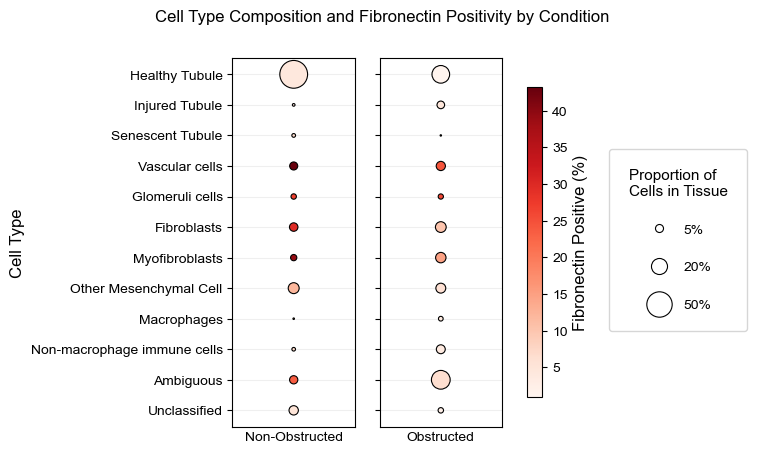

In [29]:
# Use the same stacking order as the stacked bar chart so cell types line up
# consistently across both plots.
plot_cell_type_dotplot(summary, cell_type_order=CELL_TYPE_STACK_ORDER)


## Save cell type file
This file can be imported back into QuPath to visualize the cell types.

In [ ]:
# Add the assigned Cell Type as a new column, then save the annotated data as a new TSV.
df["_markers"] = df[CLASSIFICATION_COL].apply(parse_markers)
df["Cell Type"] = df.apply(
    lambda row: assign_cell_type_row(row["_markers"], row[STRUCTURAL_REGION_COL], CELL_TYPE_RULES)[0],
    axis=1,
)
df = df.drop(columns=["_markers"])  # drop the intermediate helper column before saving

output_path = "../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_detection_measurements_with_celltype.tsv"
#df.to_csv(output_path, sep="\t", index=False)
#print(f"Saved {len(df)} rows with Cell Type column to: {output_path}")

Sanity check the new data frame:

In [31]:
df.head()

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Structural Region,...,Cell: Pan-Cytokeratin: Median,Cell: Pan-Cytokeratin: Min,Cell: Pan-Cytokeratin: Max,Cell: Pan-Cytokeratin: Std.Dev.,Cell: DRAQ5: Mean,Cell: DRAQ5: Median,Cell: DRAQ5: Min,Cell: DRAQ5: Max,Cell: DRAQ5: Std.Dev.,Cell Type
0,PPJ_07_2_Scan1_DB_cell_typed.qptiff,f7a3b208-5fef-4596-bfc6-ee811b0c3b1a,Cell,NaN,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell:...,Annotation (Tissue),Polygon,8129.2,18096.2,NaN,...,0.0,0,1,0.4880,25.6406,24.0,3,49,12.9423,Unclassified
1,PPJ_07_2_Scan1_DB_cell_typed.qptiff,83f92b7f-71fb-4a82-b8b3-12c4e06b800d,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8118.4,18096.3,NaN,...,1.0,0,2,0.6493,21.3404,18.5,2,50,13.6774,Healthy Tubule
2,PPJ_07_2_Scan1_DB_cell_typed.qptiff,117d8be0-7cb1-41e2-8747-339404f42713,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8106.6,18097.5,NaN,...,1.0,0,3,0.7402,7.1182,6.5,1,14,3.4073,Healthy Tubule
3,PPJ_07_2_Scan1_DB_cell_typed.qptiff,0d00f8cd-0f7d-4765-9835-e291c52c88d0,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8111.8,18099.6,NaN,...,1.0,0,3,0.7178,18.0000,18.0,4,32,7.9873,Healthy Tubule
4,PPJ_07_2_Scan1_DB_cell_typed.qptiff,d5f5430a-8b08-4199-8dcb-7a105c95c6a0,Cell,NaN,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,Annotation (Tissue),Polygon,8116.8,18102.9,NaN,...,1.0,0,2,0.5834,42.0301,43.0,6,79,20.2787,Healthy Tubule


In [32]:
pd.set_option('display.max_colwidth', 500)
temp_df = df.loc[df['Cell Type'] =="Unclassified",["Classification","Cell Type"]]
temp_df

,Classification,Cell Type
0,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
5,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
6,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
20,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
23,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
...,...,...
994902,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
994909,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified
994926,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA,Unclassified
994931,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-,Unclassified


In [33]:
temp_df.loc[temp_df['Classification'] =="Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb: SMA-",["Classification","Cell Type"]]

,Classification,Cell Type


In [34]:
temp_df.loc[temp_df['Classification'] =="Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb: SMA",["Classification","Cell Type"]]

,Classification,Cell Type
